# 03. Analisis exploratorio de las imagenes

Este cuaderno estudia las fotografias como fuente de datos: describe sus propiedades tecnicas, sus
atributos fotometricos, la presencia de imagenes repetidas, y las diferencias de las condiciones de
captura entre temporadas y entre los conjuntos de entrenamiento y prueba. Se apoya en la tabla de
atributos que produce `src.caracteristicas` y en los metadatos guardados por el cuaderno 01.

## Entorno

In [1]:
import sys
from pathlib import Path


def raiz_proyecto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "src").is_dir():
            return candidato
    raise RuntimeError("No se encontro la raiz del proyecto")


RAIZ = raiz_proyecto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

from src import caracteristicas, carga, graficos, tablas
from src.config import ORDEN_DANOS, UMBRAL_NITIDEZ

graficos.aplicar_estilo()

## Construccion de la tabla de atributos

Analizar las imagenes requiere convertir cada archivo en un vector de atributos medibles. El modulo
`src.caracteristicas` recorre las fotografias en paralelo y guarda el resultado en una cache de
Parquet, de modo que los analisis posteriores no vuelven a abrir los archivos originales. El proceso
es reanudable: si ya existe la cache, la construccion la reutiliza. Cada imagen se reduce a una
miniatura antes de calcular los atributos fotometricos, porque medidas como la nitidez dependen de
la resolucion y sin normalizar reflejarian el tamano del archivo en vez del contenido de la escena.

In [2]:
rutas = caracteristicas.listar_rutas_particion("train") + caracteristicas.listar_rutas_particion("test")
atributos = caracteristicas.construir_tabla(rutas, reanudar=True, guardar=True)
print(f"imagenes descritas: {len(atributos)}")
print(f"imagenes con error de lectura: {int(atributos['error'].notna().sum())}")

34731 registros ya estaban en la cache, nada que procesar
imagenes descritas: 34731
imagenes con error de lectura: 0


## Union con las etiquetas

Se combinan los metadatos de entrenamiento y prueba en un solo conjunto de etiquetas y se unen con
la tabla de atributos por la ruta relativa de la imagen, con una combinacion interna para conservar
solo las imagenes que tienen tanto etiqueta como atributos calculados. El resultado se separa en un
subconjunto de entrenamiento y uno de prueba.

In [3]:
metadatos_train = carga.cargar_metadatos("train")
metadatos_test = carga.cargar_metadatos("test")
etiquetas = pd.concat([metadatos_train, metadatos_test], ignore_index=True)

datos = etiquetas.merge(atributos, on="ruta_relativa", how="inner", suffixes=("", "_img"))
entrenamiento = datos[datos["particion"] == "train"].copy()
prueba = datos[datos["particion"] == "test"].copy()

print(f"conjunto combinado: {len(datos)} imagenes")
print(f"entrenamiento: {len(entrenamiento)} | prueba: {len(prueba)}")

conjunto combinado: 34731 imagenes
entrenamiento: 26068 | prueba: 8663


## Propiedades tecnicas de los archivos

Se describen las dimensiones, la relacion de aspecto, los megapixeles y el peso de los archivos, las
resoluciones mas frecuentes, la proporcion de imagenes verticales y los formatos. La resolucion, la
orientacion y el peso varian entre registros porque las fotografias provienen de telefonos de
distintos modelos y calidades, y estas propiedades condicionan el preprocesamiento porque cualquier
modelo de vision requiere entradas de tamano uniforme.

In [4]:
tablas.resumen_numerico(datos, ["ancho", "alto", "aspecto", "megapixeles", "peso_kb"])

,variable,conteo,faltantes,media,desviacion,minimo,q1,mediana,q3,maximo,asimetria,curtosis
0,ancho,34731,0,1037.2975,1153.4513,102.0000,320.0000,640.0000,640.0000,4608.0000,1.8944,1.9139
1,alto,34731,0,724.1993,752.7094,102.0000,320.0000,480.0000,480.0000,4160.0000,2.0562,3.0004
2,aspecto,34731,0,1.3665,0.1914,0.4500,1.3333,1.3333,1.3333,2.2222,2.5954,10.6470
3,megapixeles,34731,0,1.5852,3.2286,0.0144,0.0768,0.3072,0.3072,15.9252,2.3057,4.3587
4,peso_kb,34731,0,261.1148,498.9665,3.1900,33.6350,70.5000,111.9800,4309.9000,2.7073,7.6088


In [5]:
resolucion = datos["ancho"].astype(str) + "x" + datos["alto"].astype(str)
resolucion.value_counts().head(10)

640x480      20373
320x240       7921
3264x2448     1828
3952x1872     1531
4160x3120      782
2592x1944      565
153x204        381
2576x1932      157
4128x1952      152
3456x3456      144
Name: count, dtype: int64

In [6]:
print(f"proporcion de imagenes verticales: {datos['vertical'].mean():.4f}")
datos["formato"].value_counts()

proporcion de imagenes verticales: 0.0139


formato
JPEG    34731
Name: count, dtype: int64

In [7]:
datos.groupby("temporada", observed=True).agg(
    mediana_megapixeles=("megapixeles", "median"),
    mediana_peso_kb=("peso_kb", "median"),
    mediana_aspecto=("aspecto", "median"),
    prop_vertical=("vertical", "mean"),
).round(3)

,mediana_megapixeles,mediana_peso_kb,mediana_aspecto,prop_vertical
temporada,,,,
LR2020,0.307,73.650,1.333,0.000
SR2020,0.307,83.665,1.333,0.000
LR2021,0.307,68.255,1.333,0.000
SR2021,0.077,16.800,1.333,0.036


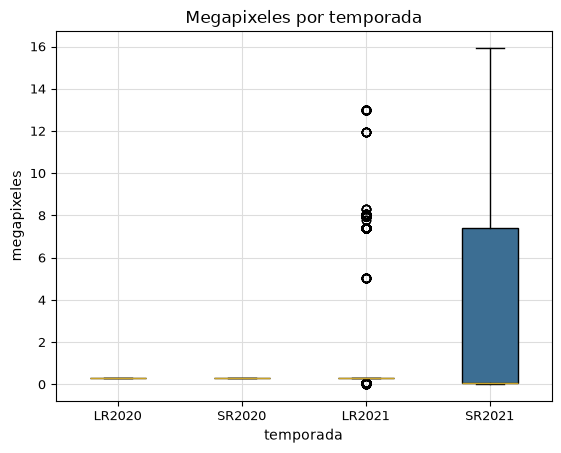

In [8]:
_ = graficos.caja_por_categoria(
    datos, "temporada", "megapixeles", "Megapixeles por temporada",
    nombre_archivo="03_caja_megapixeles_temporada",
)

## Composicion de la resolucion por temporada

Esta seccion busca el hallazgo tecnico central del cuaderno. Se cruza la temporada contra la
resolucion, reteniendo las combinaciones mas frecuentes, y se complementa con el porcentaje de
imagenes de cada temporada en tres bandas de megapixeles, cuyos limites se fijan tras inspeccionar la
distribucion real.

In [9]:
datos_resolucion = datos.assign(resolucion=datos["ancho"].astype(str) + "x" + datos["alto"].astype(str))
tabla_resolucion = datos_resolucion.pivot_table(
    index="temporada", columns="resolucion", values="ruta_relativa", aggfunc="count", fill_value=0, observed=True
)
columnas_frecuentes = tabla_resolucion.columns[tabla_resolucion.sum() >= 200]
tabla_resolucion[columnas_frecuentes].T

temporada,LR2020,SR2020,LR2021,SR2021
resolucion,,,,
153x204,0,0,0,381
2592x1944,0,0,23,542
320x240,0,0,858,7063
3264x2448,0,0,209,1619
3952x1872,0,0,224,1307
4160x3120,0,0,38,744
640x480,2725,8236,9214,198


In [10]:
datos["megapixeles"].describe()

count    34731.000000
mean         1.585192
std          3.228581
min          0.014400
25%          0.076800
50%          0.307200
75%          0.307200
max         15.925200
Name: megapixeles, dtype: float64

In [11]:
bandas_megapixeles = pd.cut(
    datos["megapixeles"], bins=[-0.01, 0.5, 5, 100],
    labels=["baja (<0.5 MP)", "media (0.5-5 MP)", "alta (>5 MP)"],
)
(pd.crosstab(datos["temporada"], bandas_megapixeles, normalize="index") * 100).round(2)

megapixeles,baja (<0.5 MP),media (0.5-5 MP),alta (>5 MP)
temporada,,,
LR2020,100.00,0.00,0.00
SR2020,100.00,0.00,0.00
LR2021,95.03,0.00,4.97
SR2021,60.89,1.48,37.63


La composicion de resolucion no es uniforme entre temporadas. Las dos temporadas mas antiguas,
LR2020 y SR2020, son homogeneas: la totalidad de sus imagenes esta en 640x480 y en la banda baja de
megapixeles. La temporada mas reciente, SR2021, es una mezcla heterogenea: cerca del 61 por ciento
en la banda baja y casi el 38 por ciento en la banda alta, con multiples resoluciones de varios
megapixeles que no aparecen en las temporadas previas. LR2021 es una etapa de transicion. Esto
indica que el proceso de preparacion de las imagenes cambio entre temporadas, un cambio anterior a
cualquier consideracion agronomica que por si solo puede explicar parte de la perdida de desempeno
entre temporadas que motiva el desafio.

## Dispositivos de captura

Se revisa cuantas imagenes conservan metadatos EXIF de la camara y como se distribuyen las marcas y
modelos declarados.

In [12]:
datos["tiene_exif"] = datos["marca"].notna()
print(f"proporcion con marca de camara declarada: {datos['marca'].notna().mean():.4f}")
display(datos["marca"].value_counts(dropna=False).head(10))
tablas.tabla_contingencia(datos, "temporada", "tiene_exif")

proporcion con marca de camara declarada: 0.0000


marca
None    34731
Name: count, dtype: int64

tiene_exif,False
temporada,
LR2020,2725
SR2020,8236
LR2021,10620
SR2021,13150


Ninguna imagen conserva metadatos EXIF de marca ni modelo. Es un resultado negativo pero relevante:
descarta atribuir las diferencias visuales entre temporadas a modelos concretos de telefono, y
obliga a apoyar el analisis unicamente en el contenido de los pixeles.

## Atributos fotometricos

Se resumen los atributos que describen cada imagen. El brillo y el contraste describen la exposicion;
la nitidez detecta imagenes desenfocadas o con movimiento; la saturacion describe la intensidad del
color; y el exceso de verde es la medida mas directamente relacionada con el estado del cultivo,
porque un cultivo afectado por sequia pierde verdor.

In [13]:
tablas.resumen_numerico(
    datos, ["brillo", "contraste", "nitidez", "saturacion", "exceso_verde", "prop_sobreexpuesta", "prop_subexpuesta"]
)

,variable,conteo,faltantes,media,desviacion,minimo,q1,mediana,q3,maximo,asimetria,curtosis
0,brillo,34731,0,111.7518,14.9465,23.4005,102.5092,111.8453,121.0073,193.9384,0.0157,1.0082
1,contraste,34731,0,61.6752,14.6284,8.6038,51.7102,61.4381,71.8472,109.2422,-0.0543,-0.1955
2,nitidez,34731,0,1408.0521,1198.1834,6.9694,601.9566,1137.9369,1878.7790,20904.9833,2.9902,21.0632
3,saturacion,34731,0,0.4189,0.1123,0.0490,0.3449,0.4212,0.4948,0.8585,-0.0730,0.0155
4,exceso_verde,34731,0,0.1412,0.1134,-0.2582,0.0601,0.1417,0.2147,1.0790,0.4032,1.2497
5,prop_sobreexpuesta,34731,0,0.0509,0.0590,0.0000,0.0034,0.0284,0.0803,0.4029,1.4371,1.7962
6,prop_subexpuesta,34731,0,0.0046,0.0117,0.0000,0.0000,0.0011,0.0045,0.3797,9.0488,139.9446


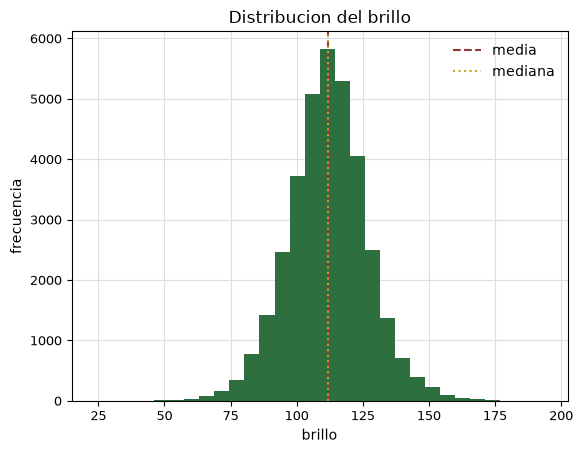

In [14]:
_ = graficos.histograma(datos["brillo"], "Distribucion del brillo", "brillo", nombre_archivo="03_histograma_brillo")

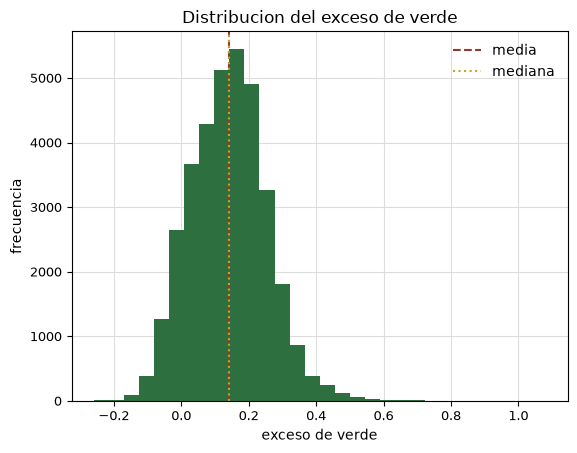

In [15]:
_ = graficos.histograma(
    datos["exceso_verde"], "Distribucion del exceso de verde", "exceso de verde",
    nombre_archivo="03_histograma_exceso_verde",
)

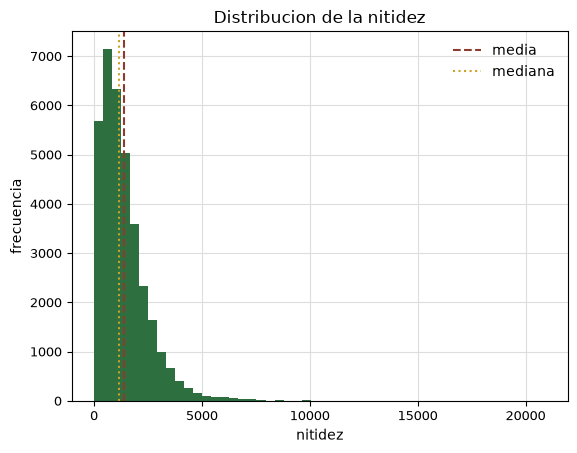

In [16]:
_ = graficos.histograma(
    datos["nitidez"], "Distribucion de la nitidez", "nitidez", bins=50, nombre_archivo="03_histograma_nitidez"
)

## Calidad de captura

Se considera desenfocada una imagen con nitidez por debajo de `UMBRAL_NITIDEZ`, y mal expuesta
aquella con mas de una quinta parte de sus pixeles en los extremos de la escala. Se calcula la
proporcion en cada categoria, en general y por temporada, y se muestran las imagenes de menor
nitidez.

In [17]:
datos["desenfocada"] = datos["nitidez"] < UMBRAL_NITIDEZ
datos["mal_expuesta"] = (datos["prop_sobreexpuesta"] + datos["prop_subexpuesta"]) > 0.2
print(f"umbral de nitidez: {UMBRAL_NITIDEZ}")
print(f"proporcion desenfocada: {datos['desenfocada'].mean():.4f}")
print(f"proporcion mal expuesta: {datos['mal_expuesta'].mean():.4f}")
datos.groupby("temporada", observed=True)[["desenfocada", "mal_expuesta"]].mean().round(4)

umbral de nitidez: 100.0
proporcion desenfocada: 0.0182
proporcion mal expuesta: 0.0358


,desenfocada,mal_expuesta
temporada,,
LR2020,0.0000,0.0521
SR2020,0.0035,0.0370
LR2021,0.0113,0.0392
SR2021,0.0367,0.0290


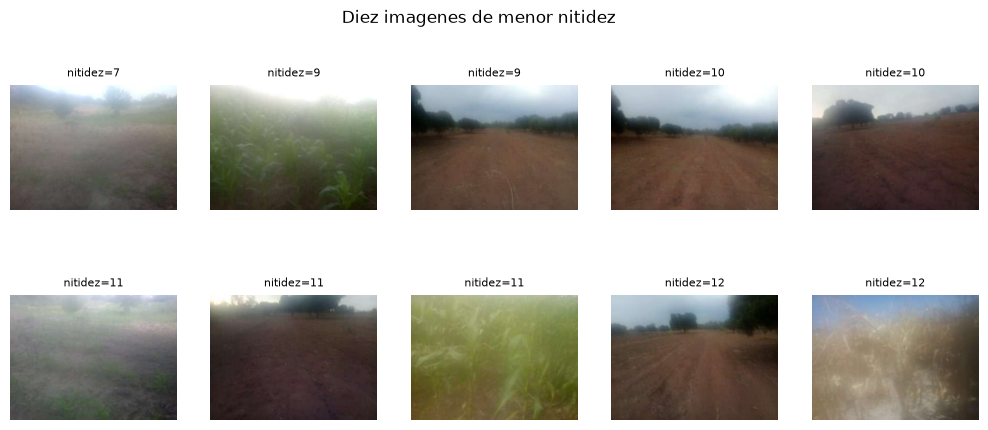

In [18]:
mas_borrosas = datos.nsmallest(10, "nitidez")
_ = graficos.mosaico_imagenes(
    mas_borrosas["ruta_relativa"].tolist(),
    [f"nitidez={valor:.0f}" for valor in mas_borrosas["nitidez"]],
    "Diez imagenes de menor nitidez", columnas=5, nombre_archivo="03_mosaico_desenfocadas",
)

La calidad de captura no es homogenea: el desenfoque se concentra en SR2021, que pasa del practicamente
nulo de LR2020 a cerca del 3.7 por ciento. Esto es coherente con la heterogeneidad de resolucion de
esa misma temporada: el cambio en el proceso de captura de SR2021 introdujo tanto resoluciones
dispares como una mayor proporcion de imagenes desenfocadas. La mala exposicion, en cambio, se
mantiene baja y estable entre temporadas.

## Imagenes repetidas

La huella perceptual permite detectar contenido repetido aunque los archivos difieran en compresion o
tamano: dos imagenes pertenecen al mismo grupo visual cuando la distancia de Hamming entre sus huellas
no supera el maximo configurado. Las huellas degeneradas, propias de imagenes de color casi uniforme,
se agrupan entre si sin que su contenido sea realmente el mismo, por lo que se excluyen antes de
agrupar.

In [19]:
degenerados = caracteristicas.detectar_hashes_degenerados(datos["hash_perceptual"])
print(f"hashes degenerados excluidos: {int(degenerados.sum())}")
validas = datos[~degenerados].copy()
validas["grupo_visual"] = caracteristicas.agrupar_duplicados(validas["hash_perceptual"].tolist())
display(caracteristicas.resumen_duplicados(validas).T)
print(f"imagenes con huella identica a otra: {int(validas['hash_perceptual'].duplicated(keep=False).sum())}")

hashes degenerados excluidos: 1


,0
total_imagenes,34730
grupos_totales,34663
imagenes_en_grupo_multiple,118
grupos_con_multiples,51
tamano_grupo_mas_grande,8


imagenes con huella identica a otra: 4


## Solapamiento visual entre particiones

Sobre los grupos visuales, se cuenta cuantos contienen imagenes de ambas particiones y cuantas
imagenes estan involucradas en esos grupos mixtos.

In [20]:
grupos_por_particiones = validas.groupby("grupo_visual")["particion"].nunique()
grupos_mixtos = grupos_por_particiones[grupos_por_particiones > 1].index
print(f"grupos visuales con imagenes de ambas particiones: {len(grupos_mixtos)}")
print(f"imagenes involucradas en grupos mixtos: {int(validas['grupo_visual'].isin(grupos_mixtos).sum())}")

grupos visuales con imagenes de ambas particiones: 21
imagenes involucradas en grupos mixtos: 55


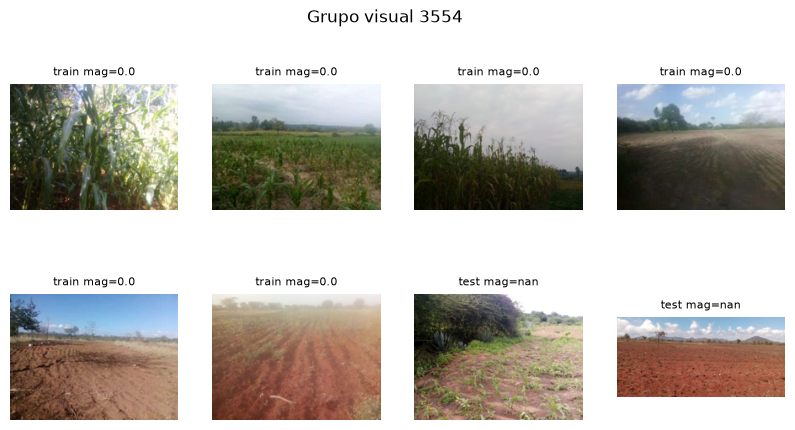

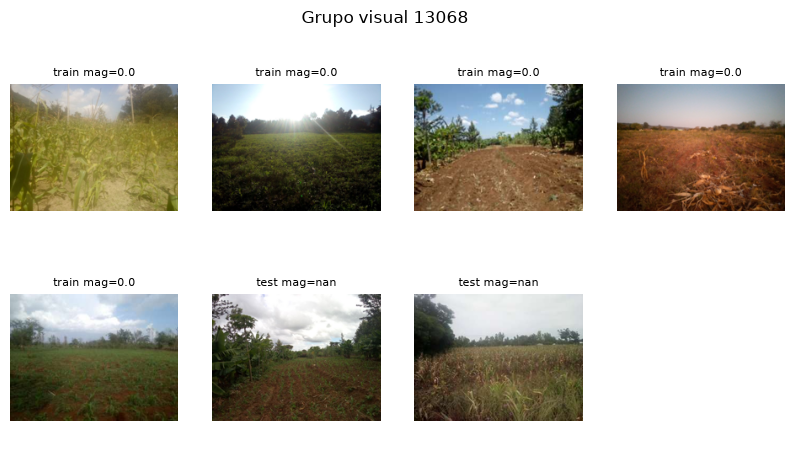

In [21]:
tamanos_mixtos = (
    validas[validas["grupo_visual"].isin(grupos_mixtos)].groupby("grupo_visual").size().sort_values(ascending=False)
)
for grupo in tamanos_mixtos.head(2).index:
    miembros = validas[validas["grupo_visual"] == grupo]
    subtitulos = [f"{particion} mag={magnitud}" for particion, magnitud in zip(miembros["particion"], miembros["magnitud"])]
    _ = graficos.mosaico_imagenes(
        miembros["ruta_relativa"].tolist(), subtitulos, f"Grupo visual {grupo}", columnas=4,
        nombre_archivo=f"03_mosaico_grupo_{grupo}",
    )

La duplicacion visual es marginal: solo unas decenas de imagenes forman grupos mixtos entre
entrenamiento y prueba. Frente a la fuga por campo documentada en el cuaderno 02, donde alrededor del
80 por ciento de los registros cae en campos compartidos, la fuga por contenido duplicado es
despreciable. El mecanismo de fuga relevante para el diseno de una validacion es el campo, no la
imagen repetida.

## Contenido visual segun la etiqueta

Se muestran ejemplos representativos por tipo de dano y ejemplos del subconjunto de sequia ordenados
por magnitud creciente, para juzgar si la diferencia entre categorias resulta apreciable a simple
vista.

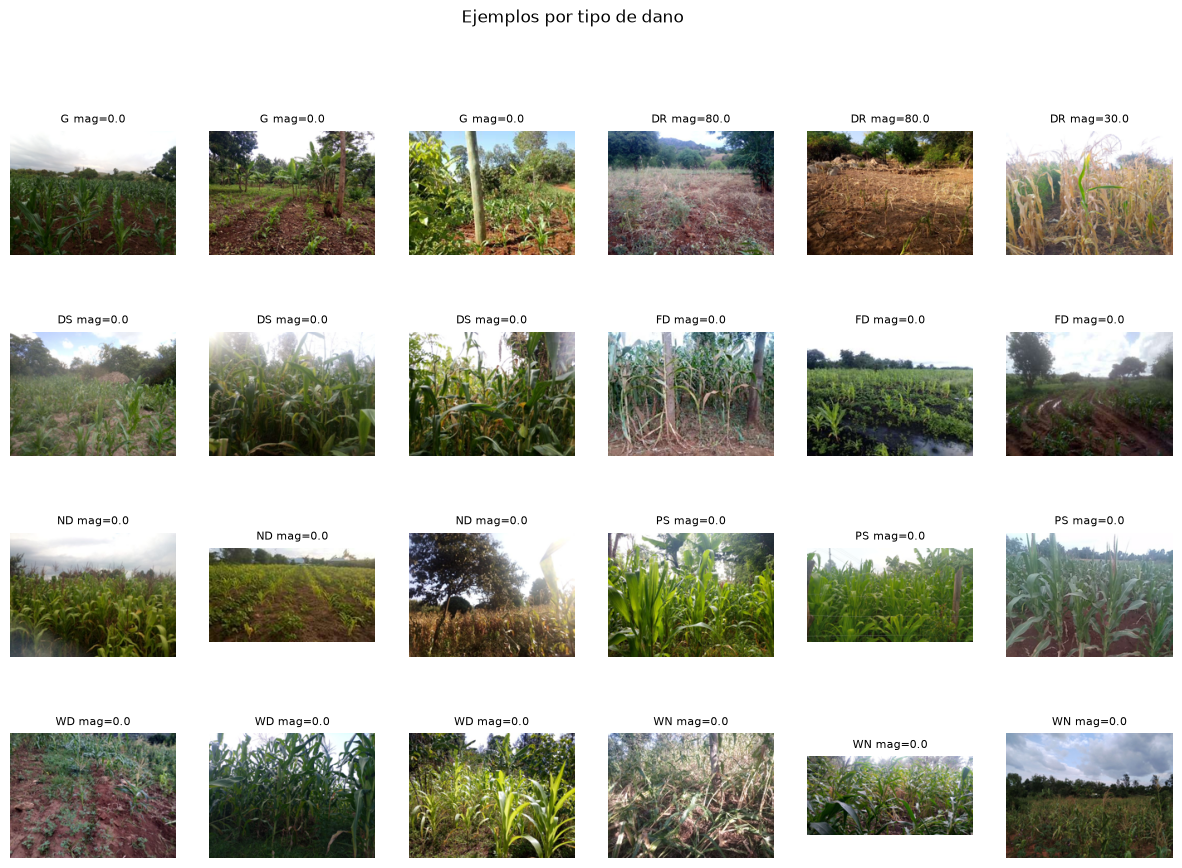

In [22]:
muestras_dano = []
for nivel in [d for d in ORDEN_DANOS if (entrenamiento["dano"] == d).any()]:
    grupo = entrenamiento[entrenamiento["dano"] == nivel]
    muestras_dano.append(grupo.sample(min(3, len(grupo)), random_state=7))
ejemplos_dano = pd.concat(muestras_dano)
_ = graficos.mosaico_imagenes(
    ejemplos_dano["ruta_relativa"].tolist(),
    [f"{dano} mag={magnitud}" for dano, magnitud in zip(ejemplos_dano["dano"], ejemplos_dano["magnitud"])],
    "Ejemplos por tipo de dano", columnas=6, nombre_archivo="03_mosaico_por_dano",
)

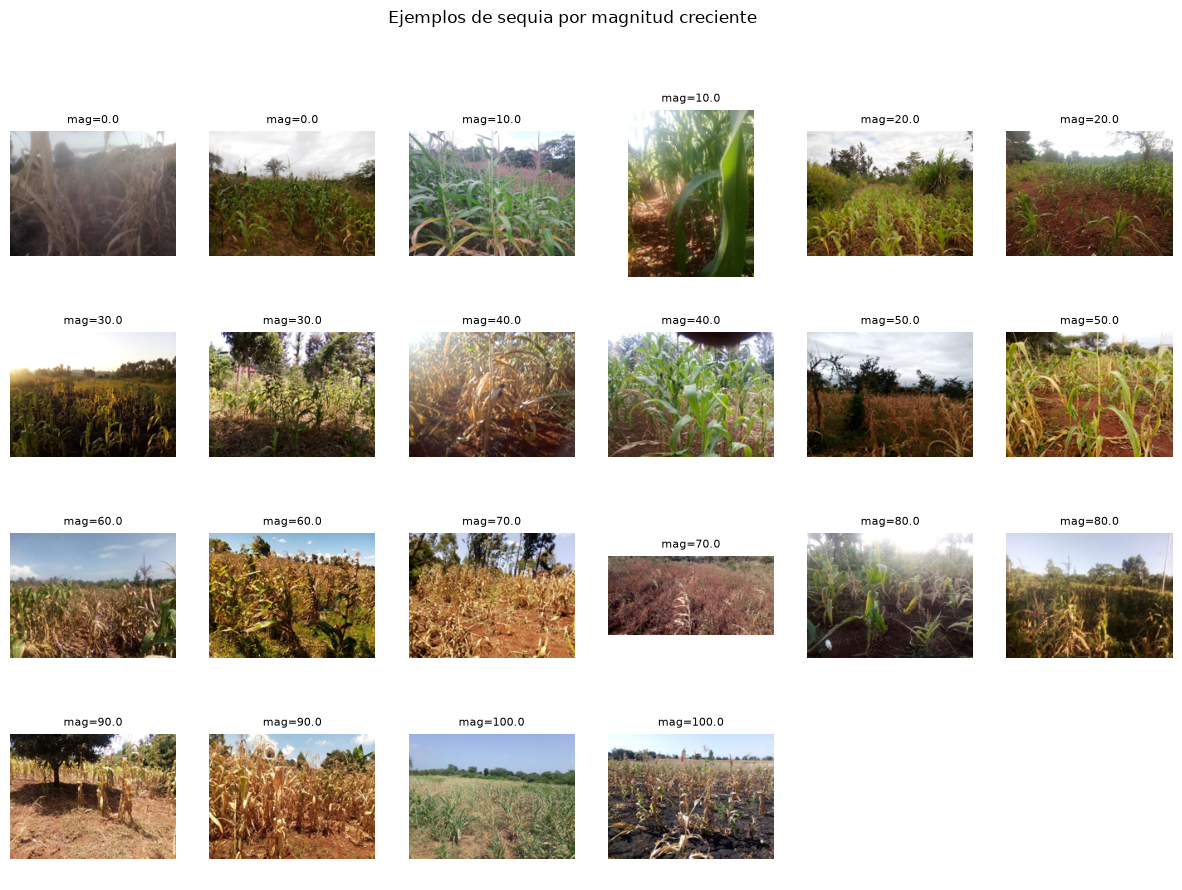

In [23]:
sequia_train = entrenamiento[entrenamiento["dano"] == "DR"]
muestras_magnitud = []
for nivel in sorted(sequia_train["magnitud"].dropna().unique()):
    grupo = sequia_train[sequia_train["magnitud"] == nivel]
    muestras_magnitud.append(grupo.sample(min(2, len(grupo)), random_state=7))
ejemplos_magnitud = pd.concat(muestras_magnitud)
_ = graficos.mosaico_imagenes(
    ejemplos_magnitud["ruta_relativa"].tolist(),
    [f"mag={magnitud}" for magnitud in ejemplos_magnitud["magnitud"]],
    "Ejemplos de sequia por magnitud creciente", columnas=6, nombre_archivo="03_mosaico_por_magnitud",
)

La diferencia entre categorias y entre niveles de magnitud no es evidente a simple vista: muchas
imagenes de sequia severa se parecen a imagenes sanas, lo que anticipa la dificultad de estimar la
magnitud visualmente y justifica un modelo capaz de captar textura y contexto.

## Relacion entre los atributos visuales y la magnitud

Se usa la correlacion de Spearman en vez de Pearson porque la magnitud es discreta y ordinal y la
relacion no tiene por que ser lineal. Se calcula sobre el subconjunto de entrenamiento.

In [24]:
atributos_foto = [
    "exceso_verde", "brillo", "contraste", "nitidez", "saturacion", "prop_sobreexpuesta", "prop_subexpuesta", "megapixeles"
]
tablas.correlacion_contra_objetivo(entrenamiento, atributos_foto, "magnitud", metodo="spearman")

,variable,coeficiente,valor_p
0,exceso_verde,-0.252229,0.000000e+00
1,prop_sobreexpuesta,-0.079985,2.889845e-38
2,prop_subexpuesta,-0.057800,9.681752e-21
3,contraste,-0.047330,2.080166e-14
4,saturacion,0.038341,5.928622e-10
5,nitidez,0.019145,1.993106e-03
6,brillo,0.007387,2.330082e-01
7,megapixeles,-0.003364,5.870236e-01


In [25]:
entrenamiento.groupby("magnitud", observed=True)[["exceso_verde", "brillo", "nitidez"]].mean().round(4)

,exceso_verde,brillo,nitidez
magnitud,,,
0.0,0.1526,111.7319,1386.4030
10.0,0.1390,112.5338,1532.9492
20.0,0.1212,110.9424,1465.2472
30.0,0.1112,110.1970,1476.5410
40.0,0.0890,111.1098,1396.0423
50.0,0.0653,111.2033,1424.5348
60.0,0.0465,112.6429,1503.1925
70.0,0.0444,113.6914,1394.0743
80.0,0.0372,114.3595,1349.6387


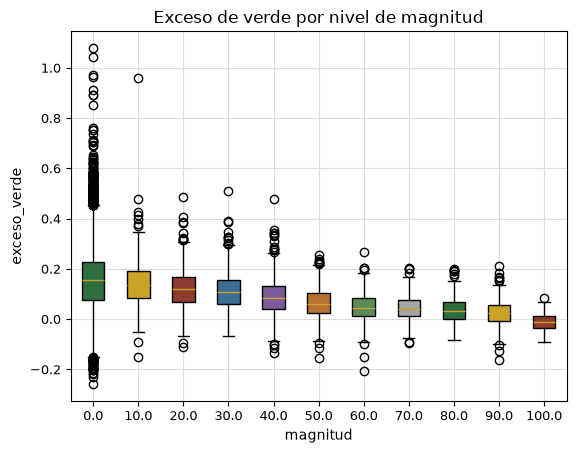

In [26]:
_ = graficos.caja_por_categoria(
    entrenamiento, "magnitud", "exceso_verde", "Exceso de verde por nivel de magnitud",
    nombre_archivo="03_caja_verde_magnitud",
)

El exceso de verde presenta la relacion mas fuerte con la magnitud, con una correlacion de Spearman
cercana a -0.25, y esa relacion es monotona: el verdor promedio decae de forma sostenida a medida que
la magnitud crece, desde un valor claramente positivo en magnitud cero hasta un valor negativo en
magnitud cien. Ningun otro atributo alcanza una asociacion comparable. Que la relacion sea solo
moderada indica que un indicador simple de verdor no basta para resolver el problema y que se requiere
un modelo capaz de captar textura y contexto.

## Relacion entre los atributos visuales y el tipo de dano

In [27]:
datos.groupby("dano", observed=True)[["exceso_verde", "brillo", "saturacion"]].mean().round(4)

,exceso_verde,brillo,saturacion
dano,,,
G,0.1368,111.4191,0.4079
DR,0.0889,111.7377,0.4279
DS,0.1872,110.6092,0.4571
FD,0.1278,110.2325,0.3505
ND,0.1175,111.5066,0.4793
PS,0.2348,112.8212,0.4373
WD,0.1699,112.1748,0.4258
WN,0.1484,110.7751,0.3690


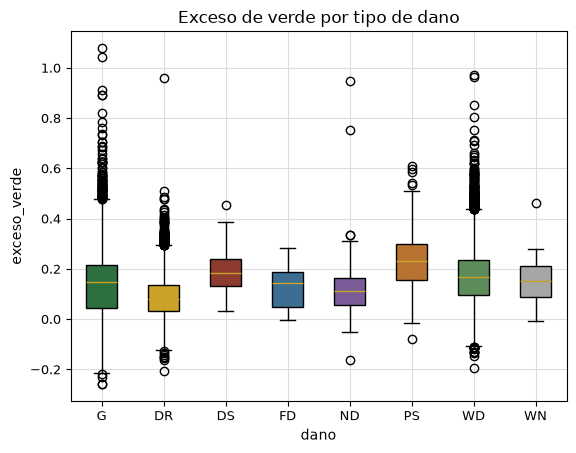

In [28]:
_ = graficos.caja_por_categoria(
    datos, "dano", "exceso_verde", "Exceso de verde por tipo de dano", nombre_archivo="03_caja_verde_dano"
)

## Diferencias entre temporadas en las imagenes

Si las condiciones de captura cambian entre temporadas, un modelo ajustado sobre las primeras aprende
parte de esas condiciones y falla al aplicarse a la siguiente. Se comparan los atributos por temporada
y se contrastan las tres primeras temporadas contra la ultima disponible mediante la prueba de
Kolmogorov y Smirnov.

In [29]:
datos.groupby("temporada", observed=True)[atributos_foto].mean().round(3)

,exceso_verde,brillo,contraste,nitidez,saturacion,prop_sobreexpuesta,prop_subexpuesta,megapixeles
temporada,,,,,,,,
LR2020,0.169,112.073,67.573,1602.472,0.446,0.067,0.004,0.307
SR2020,0.135,111.446,61.945,1691.869,0.454,0.052,0.005,0.307
LR2021,0.153,112.297,63.639,1346.249,0.428,0.059,0.004,0.674
SR2021,0.130,111.437,58.698,1239.918,0.384,0.040,0.005,3.386


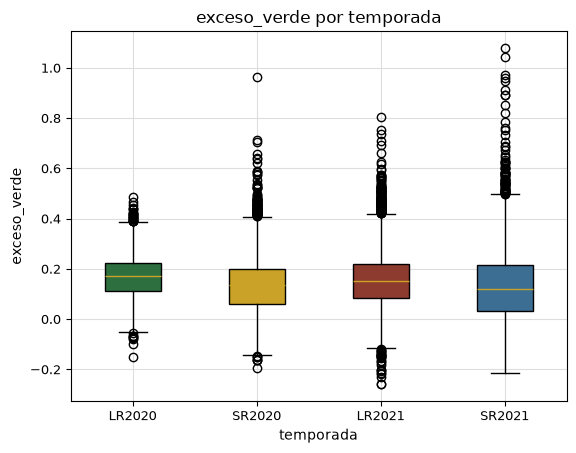

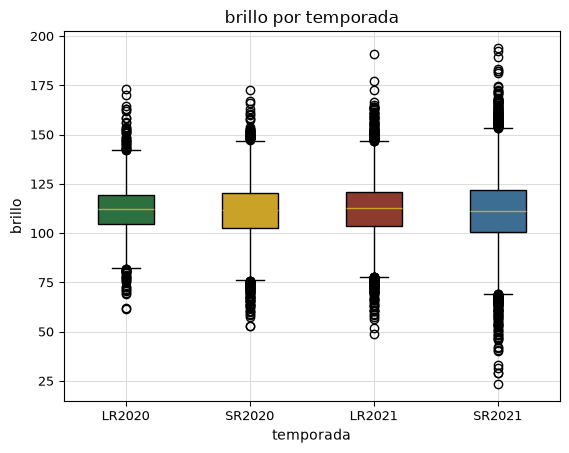

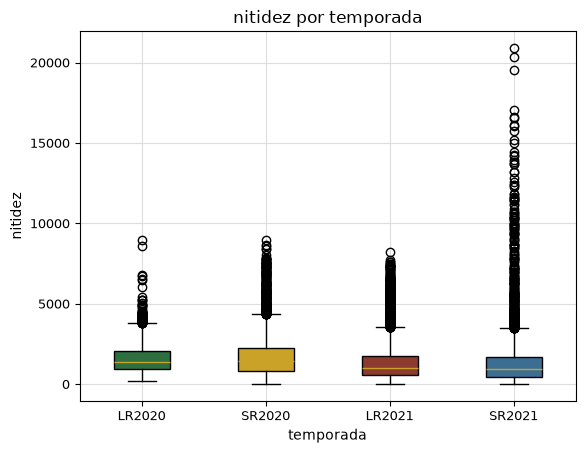

In [30]:
for atributo, nombre_figura in (
    ("exceso_verde", "03_caja_exceso_verde_temporada"),
    ("brillo", "03_caja_brillo_temporada"),
    ("nitidez", "03_caja_nitidez_temporada"),
):
    _ = graficos.caja_por_categoria(datos, "temporada", atributo, f"{atributo} por temporada", nombre_archivo=nombre_figura)

In [31]:
ultima_temporada = "SR2021"
primeras_temporadas = datos[datos["temporada"] != ultima_temporada]
imagenes_ultima = datos[datos["temporada"] == ultima_temporada]
tablas.comparar_variables_numericas(primeras_temporadas, imagenes_ultima, atributos_foto, etiquetas=("primeras", "SR2021"))

,variable,media_primeras,media_SR2021,diferencia_relativa,estadistico_ks,valor_p
0,megapixeles,0.487651,3.386412,-0.855998,0.553156,0.000000e+00
1,saturacion,0.440344,0.383625,0.147849,0.219253,0.000000e+00
2,prop_sobreexpuesta,0.057304,0.040365,0.419636,0.176040,5.919424e-222
3,contraste,63.489173,58.698208,0.081620,0.144379,4.226053e-149
4,exceso_verde,0.147904,0.130194,0.136025,0.133273,5.052964e-127
5,nitidez,1510.501757,1239.917800,0.218227,0.127278,7.537526e-116
6,prop_subexpuesta,0.004562,0.004608,-0.009978,0.102263,7.556176e-75
7,brillo,111.943889,111.436503,0.004553,0.058884,4.542412e-25


El mayor desplazamiento entre las primeras temporadas y SR2021 esta en los megapixeles, con un
estadistico de Kolmogorov y Smirnov superior a 0.55: SR2021 tiene una resolucion mucho mayor. Le
siguen la saturacion, la nitidez y el exceso de verde, todos menores en SR2021. El desplazamiento
fotometrico entre temporadas esta encabezado por la propiedad tecnica que ya identificamos en la
composicion de resolucion, lo que refuerza que el cambio de captura, y no solo el estado del cultivo,
separa a SR2021 de las temporadas anteriores.

## Diferencias entre entrenamiento y prueba en las imagenes

Se repite la comparacion de Kolmogorov y Smirnov entre entrenamiento y prueba.

In [32]:
tablas.comparar_variables_numericas(entrenamiento, prueba, atributos_foto, etiquetas=("train", "test"))

,variable,media_train,media_test,diferencia_relativa,estadistico_ks,valor_p
0,nitidez,1398.295169,1437.411869,-0.027213,0.013716,0.171528
1,contraste,61.710402,61.569260,0.002292,0.010298,0.492319
2,exceso_verde,0.141613,0.139953,0.011859,0.009898,0.543823
3,saturacion,0.418983,0.418523,0.001100,0.009414,0.608486
4,prop_subexpuesta,0.004553,0.004661,-0.023116,0.008408,0.744113
5,prop_sobreexpuesta,0.050790,0.051192,-0.007857,0.008028,0.793013
6,brillo,111.744733,111.772986,-0.000253,0.007674,0.835522
7,megapixeles,1.588710,1.574608,0.008956,0.005969,0.973614


Las diferencias entre entrenamiento y prueba son minimas: todos los estadisticos de Kolmogorov y
Smirnov quedan por debajo de 0.02 y ninguno es significativo. Contrastadas con el fuerte
desplazamiento entre temporadas de la seccion anterior, confirman que el desplazamiento relevante
ocurre entre temporadas y no es visible al evaluar sobre la particion oficial de la competencia, en
linea con lo que el cuaderno 02 encontro sobre las etiquetas.

## Cierre de la etapa

Los atributos visuales completan el diagnostico iniciado con las etiquetas: la resolucion y la calidad
de captura cambian de forma marcada en SR2021, el exceso de verde mantiene una relacion monotona pero
moderada con la magnitud, la duplicacion visual es despreciable frente a la fuga por campo, y el
desplazamiento entre temporadas se manifiesta con claridad en las imagenes aunque no entre
entrenamiento y prueba. El informe final consolida los hallazgos de los tres cuadernos y define los
siguientes pasos del proyecto.